# Seasonality (Tính mùa vụ) của Time Series (Chuỗi thời gian)



## Giới thiệu


Seasonality (Tính mùa vụ) là một khía cạnh quan trọng của Time-Series Analysis (Phân tích chuỗi thời gian). Vì Time-Series (Chuỗi thời gian) được đánh chỉ số theo thời gian, chúng chịu ảnh hưởng của Seasonal Fluctuations (Biến động theo mùa). Ví dụ, chúng ta kỳ vọng doanh số bán kem sẽ cao hơn vào các tháng mùa hè và thấp hơn vào các tháng mùa đông.


Seasonality (Tính mùa vụ) có thể xuất hiện ở các khoảng thời gian khác nhau như ngày, tuần hoặc tháng. Chìa khóa cho Time-Series Analysis (Phân tích chuỗi thời gian) là hiểu Seasonality (Tính mùa vụ) ảnh hưởng đến Series (Chuỗi) của chúng ta như thế nào, do đó tạo ra các Forecast (Dự báo) tốt hơn cho tương lai.


Cách dễ nhất để xử lý Seasonality (Tính mùa vụ) là loại bỏ nó và làm cho **Time-Series (Chuỗi thời gian) của chúng ta Stationary (Dừng)**, đây là yêu cầu của hầu hết các Forecasting Model (Mô hình dự báo). Tuy nhiên, có các Model (Mô hình) như SARIMA mô hình hóa các ảnh hưởng mùa vụ cho bạn.


## Xem Seasonality (Tính mùa vụ)



In [1]:
# Import các thư viện
import plotly.express as px
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import numpy as np


In [2]:
# Đọc dữ liệu
data = pd.read_csv('AirPassengers.csv')


In [3]:
def plotting(title, data, x, y, x_label, y_label):
    """Hàm chung để vẽ biểu đồ dữ liệu hành khách."""
    fig = px.line(data, x=data[x], y=data[y], labels={x: x_label, y: y_label})

    fig.update_layout(template="simple_white", font=dict(size=18),
                      title_text=title, width=650,
                      title_x=0.5, height=400)

    fig.show()


In [4]:
# Vẽ biểu đồ dữ liệu hành khách hàng không
plotting(title='Airline Passengers', data=data, x='Month',
         y='#Passengers', x_label='Date', y_label='Passengers')


Dữ liệu được đánh chỉ số theo tháng và chúng ta có thể thấy rõ một Seasonal Pattern (Mẫu mùa vụ) hàng năm trong đó số lượng hành khách đạt đỉnh vào các tháng mùa hè. Ngoài ra còn có Trend (Xu hướng) tổng thể là số lượng hành khách tăng theo thời gian.


## Loại bỏ Seasonality (Tính mùa vụ)


Chúng ta có thể loại bỏ Seasonality (Tính mùa vụ) trong dữ liệu bằng cách sử dụng Seasonal Differencing (Lấy sai phân mùa vụ). Phương pháp này tính toán sự khác biệt giữa giá trị hiện tại và giá trị của nó trong mùa trước. Lý do làm điều này là để làm cho Time Series (Chuỗi thời gian) Stationary (Dừng), khiến các thuộc tính thống kê của nó không đổi theo thời gian. Seasonality (Tính mùa vụ) khiến Mean (Trung bình) của Time Series (Chuỗi thời gian) khác nhau khi chúng ta ở một mùa cụ thể. Do đó, các thuộc tính thống kê của nó không cố định.


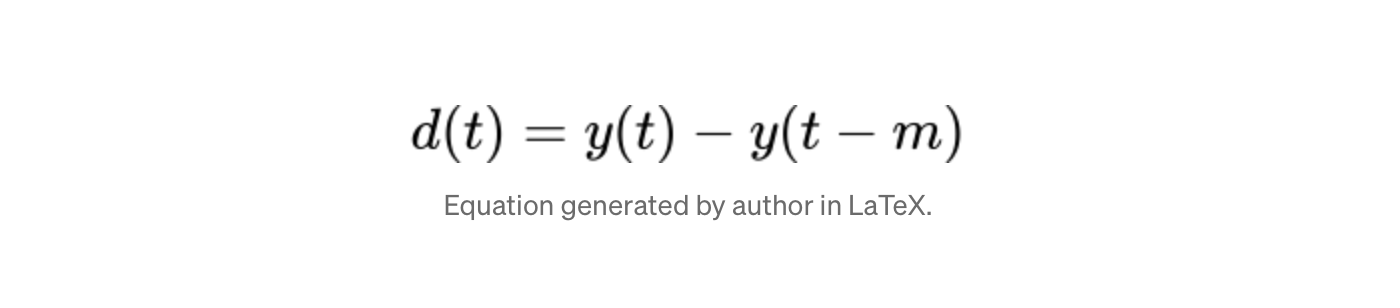

Trong đó d(t) là điểm dữ liệu đã Differenced (Lấy sai phân) tại thời điểm t, y(t) là giá trị của Series (Chuỗi) tại t, y(t-m) là giá trị của điểm dữ liệu ở mùa trước và m là độ dài của một mùa. Trong trường hợp của chúng ta m=12 vì chúng ta có Seasonality (Tính mùa vụ) hàng năm.


In [5]:
# Lấy seasonal difference và vẽ biểu đồ
data["Passenger_Season_Diff"] = data["#Passengers"].diff(periods=12)

plotting(title='Airline Passengers', data=data, x='Month', y='Passenger_Season_Diff',
         x_label='Date', y_label='Passenger<br>Seasonal Difference')


Seasonality (Tính mùa vụ) hàng năm đã biến mất, tuy nhiên chúng ta bây giờ quan sát thấy một số Cycle (Chu kỳ). Đây là một đặc điểm phổ biến khác của Time Series (Chuỗi thời gian), tương tự như Seasonality (Tính mùa vụ) nhưng thường ở quy mô thời gian dài hơn như quan sát thấy ở đây.


## ADF Test (Kiểm định ADF)


Chúng ta có thể kiểm tra rằng Series (Chuỗi) kết quả là Stationary (Dừng) bằng cách sử dụng Augmented Dickey-Fuller (ADF) Test (Kiểm định ADF). Null Hypothesis (Giả thuyết không) của Test (Kiểm định) này là Series (Chuỗi) không Stationary (Dừng). Thư viện statsmodels cung cấp một hàm để thực hiện ADF Test (Kiểm định ADF):


In [6]:
def adf_test(series):
    """Sử dụng ADF test để xác định xem một series có stationary không"""
    test_results = adfuller(series)
    print('ADF Statistic: ', test_results[0])
    print('P-Value: ', test_results[1])
    print('Critical Values:')
    for thres, adf_stat in test_results[4].items():
        print('\t%s: %.2f' % (thres, adf_stat))


adf_test(data["Passenger_Season_Diff"][12:])


ADF Statistic:  -3.383020726492481
P-Value:  0.011551493085514954
Critical Values:
	1%: -3.48
	5%: -2.88
	10%: -2.58


P-Value thấp hơn ngưỡng 5% và 10%, nhưng cao hơn ngưỡng 1%. Do đó, tùy thuộc vào Significance Level (Mức ý nghĩa) của bạn, chúng ta có thể xác nhận hoặc phủ nhận thống kê rằng Series (Chuỗi) của chúng ta là Stationary (Dừng).


Chúng ta cũng có thể thực hiện thêm một số Regular Differencing (Lấy sai phân thông thường) (sự khác biệt giữa các giá trị liền kề) để giảm thêm P-Value. Tuy nhiên, trong trường hợp này tôi nghĩ dữ liệu là đủ Stationary (Dừng) vì nó dưới ngưỡng 5%.
